<a href="https://colab.research.google.com/github/Krish-sharma-2003/ML-s-Google-Colab-Practice-Notes/blob/main/Momentum_Gradient_v_s_Vanilla_Gradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [289]:
import numpy as np
import matplotlib.pyplot as plt

In [290]:
def quadratic_loss(x, y):
  return x**2 + 10 * y**2


In [291]:
def quadratic_grad(x, y):
  dx = 2 * x
  dy = 20 * y
  return np.array([dx, dy])


In [292]:
def batch_gradient_descent(grad_func, eta, epochs, start_point):
  x,y = start_point
  path = [(x, y)]
  losses = [quadratic_loss(x, y)]

  for _ in range(epochs):
      grad = grad_func(x, y)
      x -= eta * grad[0]
      y -= eta * grad[1]
      path.append((x, y))
      losses.append(quadratic_loss(x, y))

  return np.array(path), losses

In [293]:
def gradient_descent_momentum(grad_func, eta, beta, epochs, start_point):
  x, y = start_point
  v = np.array([0, 0])
  path = [(x, y)]
  losses = [(quadratic_loss(x, y))]

  for  _ in range(epochs):
       grad = grad_func(x, y)
       v = beta * v + (1 - beta) * grad
       x -= eta * v[0]
       y -= eta * v[1]
       path.append((x, y))
       losses.append(quadratic_loss(x, y))

  return np.array(path), losses


In [294]:
def plot_paths(function, paths, labels, title):
    x, y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    z = function(x, y)

    plt.figure(figsize=(8, 6))
    plt.contour(x, y, z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label="start")
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label="end")

    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()


In [295]:
def plot_losses(losses, labels, title):
  plt.figure(figsize=(8, 6))

  for loss, label in zip(losses, labels):

      plt.plot(loss, label=label)

  plt.title(title)
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

In [296]:
eta_bgd = 0.1            #Learning rate for BGD
eta_momentum = 0.1       #Learing rate for MOmentum
beta = 0.9               #Momentum coefficient
epochs = 50
start_point = (1.5, 1.5) # Initial point far from the minimum

In [297]:
path_bgd, losses_bgd = batch_gradient_descent(quadratic_grad, eta_bgd, epochs, start_point)
path_momentum, losses_momentum = gradient_descent_momentum(quadratic_grad, eta_momentum, beta, epochs, start_point)

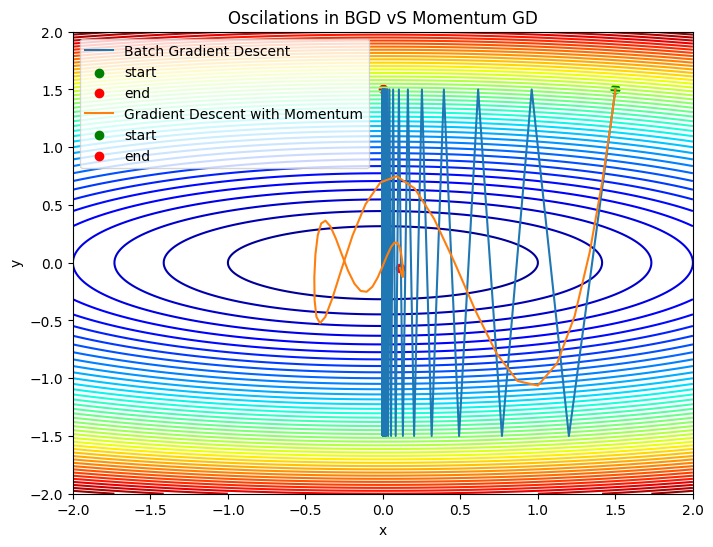

In [298]:
plot_paths(quadratic_loss, [path_bgd, path_momentum],
           ["Batch Gradient Descent", "Gradient Descent with Momentum"],
           "Oscilations in BGD vS Momentum GD")

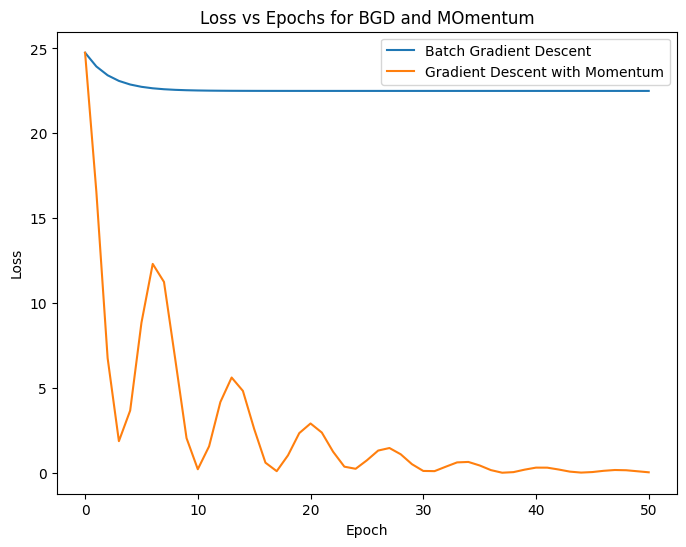

In [299]:
plot_losses([losses_bgd, losses_momentum],
            ["Batch Gradient Descent", "Gradient Descent with Momentum"],
            "Loss vs Epochs for BGD and MOmentum")

In [300]:
losses_momentum

[24.75,
 np.float64(16.560900000000004),
 np.float64(6.759264960000003),
 np.float64(1.8675617466240004),
 np.float64(3.672309319744665),
 np.float64(8.843285183359708),
 np.float64(12.3094918926023),
 np.float64(11.246403281338745),
 np.float64(6.686816378009605),
 np.float64(2.0465781414119),
 np.float64(0.2126613066115431),
 np.float64(1.5633691099715803),
 np.float64(4.169226890507775),
 np.float64(5.615916031069389),
 np.float64(4.828945682317156),
 np.float64(2.586386989647691),
 np.float64(0.6001722393401042),
 np.float64(0.09975398411450212),
 np.float64(1.0327334898955147),
 np.float64(2.3409973655715195),
 np.float64(2.9093329693459866),
 np.float64(2.3758076666698544),
 np.float64(1.2466953211027911),
 np.float64(0.36527537417011696),
 np.float64(0.23962892251629297),
 np.float64(0.7400786370228303),
 np.float64(1.3137408447015861),
 np.float64(1.463318654920823),
 np.float64(1.0950673284048806),
 np.float64(0.5101399292379962),
 np.float64(0.1132104831574299),
 np.float64(0

In [301]:
path_momentum

array([[ 1.50000000e+00,  1.50000000e+00],
       [ 1.47000000e+00,  1.20000000e+00],
       [ 1.41360000e+00,  6.90000000e-01],
       [ 1.33456800e+00,  9.30000000e-02],
       [ 1.23674784e+00, -4.62900000e-01],
       [ 1.12397474e+00, -8.70630000e-01],
       [ 9.99999454e-01, -1.06346100e+00],
       [ 8.68421708e-01, -1.02431670e+00],
       [ 7.32633302e-01, -7.84223490e-01],
       [ 5.95771071e-01, -4.11294903e-01],
       [ 4.60679642e-01,  6.59980590e-03],
       [ 3.29883762e-01,  3.81385083e-01],
       [ 2.05569796e-01,  6.42414815e-01],
       [ 8.95758299e-02,  7.48858612e-01],
       [-1.66102559e-02,  6.94886306e-01],
       [-1.11845528e-01,  5.07333970e-01],
       [-1.95320362e-01,  2.37070073e-01],
       [-2.66541306e-01, -5.35814485e-02],
       [-3.25309329e-01, -3.04451528e-01],
       [-3.71694364e-01, -4.69344294e-01],
       [-4.06007007e-01, -5.23878925e-01],
       [-4.28768246e-01, -4.68184307e-01],
       [-4.40677997e-01, -3.24422290e-01],
       [-4.